In [12]:
import os
from typing import Optional, List, Tuple
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from dotenv import load_dotenv

In [2]:
CITYSCAPES_COLORS = {
    0: (128, 64, 128),      # road
    1: (244, 35, 232),      # sidewalk
    2: (70, 70, 70),        # building
    3: (102, 102, 156),     # wall
    4: (190, 153, 153),     # fence
    5: (153, 153, 153),     # pole
    6: (250, 170, 30),      # traffic light
    7: (220, 220, 0),       # traffic sign
    8: (107, 142, 35),      # vegetation
    9: (152, 251, 152),     # terrain
    10: (70, 130, 180),     # sky
    11: (220, 20, 60),      # person
    12: (255, 0, 0),        # rider
    13: (0, 0, 142),        # car
    14: (0, 0, 70),         # truck
    15: (0, 60, 100),       # bus
    16: (0, 80, 100),       # train
    17: (0, 0, 230),        # motorcycle
    18: (119, 11, 32),      # bicycle
}

CITYSCAPES_CLASS_NAMES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
    'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky',
    'person', 'rider', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

In [3]:
def verify_cityscapes_structure(base_dir: str) -> Tuple[bool, dict]:

    report = {'errors': [], 'warnings': [], 'found_dirs': []}



    expected_dirs = ['gtFine', 'leftImg8bit']

    for dirname in expected_dirs:

        dir_path = os.path.join(base_dir, dirname)

        if os.path.isdir(dir_path):

            report['found_dirs'].append(dirname)



            for split in ['train', 'val']:

                split_path = os.path.join(dir_path, split)

                if not os.path.isdir(split_path):

                    report['warnings'].append(

                        f"Отсутствует ожидаемая поддиректория: {split_path}"

                    )

        else:

            report['errors'].append(f"Отсутствует обязательная директория: {dir_path}")



    is_valid = len(report['errors']) == 0



    if is_valid:

        print("Структура датасета: ОК")

    else:

        print("Ошибки в структуре датасета:")

        for err in report['errors']:

            print(f"  - {err}")



    return is_valid, report

In [4]:
def check_dataset_integrity(img_dir: str, mask_dir: str) -> dict:
    print(f"\n--- Проверка целостности датасета ---")
    print(f"Изображения: {img_dir}")
    print(f"Маски: {mask_dir}")

    results = {
        'total_images': 0,
        'total_masks': 0,
        'matching_pairs': 0,
        'missing_masks': [],
        'missing_images': [],
        'class_distribution': np.zeros(35),
        'errors': []
    }

    try:
        img_files = set(os.listdir(img_dir))
        mask_files = set(os.listdir(mask_dir))
    except FileNotFoundError as e:
        results['errors'].append(f"Директория не найдена: {e}")
        return results

    img_names = {f.replace('_leftImg8bit.png', '') for f in img_files if f.endswith('_leftImg8bit.png')}
    mask_names = {f.replace('_gtFine_labelIds.png', '') for f in mask_files if f.endswith('_gtFine_labelIds.png')}

    results['total_images'] = len(img_names)
    results['total_masks'] = len(mask_names)

    missing_masks = img_names - mask_names
    missing_images = mask_names - img_names

    results['missing_masks'] = list(missing_masks)[:10]
    results['missing_images'] = list(missing_images)[:10]
    results['matching_pairs'] = len(img_names & mask_names)

    print(f"Всего изображений: {results['total_images']}")
    print(f"Всего масок: {results['total_masks']}")
    print(f"Совпадающих пар: {results['matching_pairs']}")

    if missing_masks:
        print(f"Предупреждение: Отсутствуют маски для {len(missing_masks)} изображений")
    if missing_images:
        print(f"Предупреждение: Отсутствуют изображения для {len(missing_images)} масок")

    print("\nАнализ распределения классов...")
    class_counts = np.zeros(35)
    total_pixels = 0

    for mask_file in mask_files:
        if not mask_file.endswith('_gtFine_labelIds.png'):
            continue

        mask_path = os.path.join(mask_dir, mask_file)
        try:
            mask = Image.open(mask_path)
            mask_arr = np.array(mask)
            unique, counts = np.unique(mask_arr, return_counts=True)

            for class_id, count in zip(unique, counts):
                if class_id < 35:
                    class_counts[class_id] += count
                    total_pixels += count
        except Exception as e:
            results['errors'].append(f"Ошибка при чтении маски {mask_file}: {e}")

    results['class_distribution'] = class_counts

    print("\nРаспределение классов (первые 19):")
    print(f"{'Класс':<20} {'Пикселей':>12} {'Процент':>10}")
    print("-" * 45)

    for class_id in range(19):
        count = int(class_counts[class_id])
        percentage = (count / total_pixels * 100) if total_pixels > 0 else 0
        class_name = CITYSCAPES_CLASS_NAMES[class_id]
        print(f"{class_name:<20} {count:>12,} {percentage:>9.2f}%")

    if total_pixels > 0:
        max_class = np.argmax(class_counts[:19])
        min_class = np.argmin([c for c in class_counts[:19] if c > 0])
        ratio = class_counts[max_class] / class_counts[min_class] if class_counts[min_class] > 0 else float('inf')
        print(f"\nДисбаланс классов: самый частый '{CITYSCAPES_CLASS_NAMES[max_class]}' "
              f"в {ratio:.1f} раз чаще самого редкого")

    return results

In [5]:
def visualize_sample(img_path: str, mask_path: str, output_path: Optional[str] = None):
    print(f"\n--- Визуализация образца ---")
    print(f"Изображение: {img_path}")
    print(f"Маска: {mask_path}")

    img = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path)
    mask_arr = np.array(mask)

    color_mask = np.zeros((mask_arr.shape[0], mask_arr.shape[1], 3), dtype=np.uint8)
    for class_id, color in CITYSCAPES_COLORS.items():
        if class_id < 19:
            color_mask[mask_arr == class_id] = color

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img)
    axes[0].set_title("Исходное изображение", fontsize=10, fontweight='bold')
    axes[0].axis('off')

    im1 = axes[1].imshow(mask_arr, cmap='gray', vmin=0, vmax=18)
    axes[1].set_title("Маска (grayscale)", fontsize=10, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(color_mask)
    axes[2].set_title("Цветная сегментация", fontsize=10, fontweight='bold')
    axes[2].axis('off')

    overlay = img.copy()
    overlay_array = np.array(overlay)
    alpha = 0.5
    blend = (overlay_array * (1 - alpha) + color_mask * alpha).astype(np.uint8)
    axes[3].imshow(blend)
    axes[3].set_title("Наложение (alpha=0.5)", fontsize=10, fontweight='bold')
    axes[3].axis('off')

    plt.suptitle(f"CityScapes Sample: {os.path.basename(img_path)}", fontsize=12, fontweight='bold')
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Сохранено: {output_path}")

    plt.show()

    unique, counts = np.unique(mask_arr, return_counts=True)
    print("\nКлассы в данной маске:")
    total_pixels = mask_arr.size
    for class_id, count in zip(unique, counts):
        if class_id < 19 and count > 100:
            percentage = count / total_pixels * 100
            class_name = CITYSCAPES_CLASS_NAMES[class_id]
            print(f"  {class_name:<15}: {count:>8,} пикселей ({percentage:5.2f}%)")

In [6]:
def find_sample_pair(base_dir: str, split: str = 'train') -> Tuple[str, str]:
    img_split_dir = os.path.join(base_dir, 'leftImg8bit', split)
    mask_split_dir = os.path.join(base_dir, 'gtFine', split)

    if not os.path.exists(img_split_dir) or not os.path.exists(mask_split_dir):
        raise FileNotFoundError(f"Директории сплита '{split}' не найдены")

    cities = os.listdir(img_split_dir)
    for city in cities:
        city_img_dir = os.path.join(img_split_dir, city)
        city_mask_dir = os.path.join(mask_split_dir, city)

        if os.path.isdir(city_img_dir) and os.path.isdir(city_mask_dir):
            img_files = [f for f in os.listdir(city_img_dir) if f.endswith('_leftImg8bit.png')]
            if img_files:
                img_name = img_files[0]
                base_name = img_name.replace('_leftImg8bit.png', '')

                img_path = os.path.join(city_img_dir, img_name)
                mask_path = os.path.join(city_mask_dir, f"{base_name}_gtFine_labelIds.png")

                if os.path.exists(mask_path):
                    return img_path, mask_path

    raise FileNotFoundError(f"Не найдено пар изображение-маска в сплите '{split}'")

In [7]:
def plot_class_distribution_bar(mask_dir: str, output_path: Optional[str] = None):
    print(f"\n--- Анализ распределения классов ---")
    print(f"Директория с масками: {mask_dir}")

    class_pixels = np.zeros(19)
    total_masks = 0

    for root, dirs, files in os.walk(mask_dir):
        for file in files:
            if file.endswith('_gtFine_labelIds.png'):
                mask_path = os.path.join(root, file)
                try:
                    mask = np.array(Image.open(mask_path))
                    for class_id in range(19):
                        class_pixels[class_id] += np.sum(mask == class_id)
                    total_masks += 1
                except Exception as e:
                    print(f"Ошибка при чтении {file}: {e}")

    print(f"Обработано масок: {total_masks}")

    total_pixels = class_pixels.sum()
    percentages = (class_pixels / total_pixels * 100) if total_pixels > 0 else np.zeros(19)

    plt.figure(figsize=(14, 7))
    bars = plt.bar(range(len(CITYSCAPES_CLASS_NAMES)), percentages, color='steelblue', alpha=0.7)

    plt.xticks(range(len(CITYSCAPES_CLASS_NAMES)), CITYSCAPES_CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    plt.ylabel("Процент пикселей (%)", fontsize=10)
    plt.title("Распределение классов в CityScapes", fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    for bar, pct in zip(bars, percentages):
        if pct > 0.1:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"График сохранён: {output_path}")

    plt.show()

    sorted_idx = np.argsort(percentages)[::-1]
    print("\nТоп-5 самых частых классов:")
    for i in sorted_idx[:5]:
        print(f"  {i+1}. {CITYSCAPES_CLASS_NAMES[i]}: {percentages[i]:.2f}%")

    print("\nТоп-5 самых редких классов:")
    for i in sorted_idx[-5:][::-1]:
        print(f"  {i+1}. {CITYSCAPES_CLASS_NAMES[i]}: {percentages[i]:.2f}%")

Ошибки в структуре датасета:
  - Отсутствует обязательная директория: /data/raw/cityscapes\gtFine
  - Отсутствует обязательная директория: /data/raw/cityscapes\leftImg8bit

Критические ошибки! Остановка.
Ошибка при проверке целостности: [WinError 3] Системе не удается найти указанный путь: '/data/raw/cityscapes\\leftImg8bit\\train'

--- Анализ распределения классов ---
Директория с масками: /data/raw/cityscapes\gtFine\train
Обработано масок: 0
График сохранён: /data/raw/cityscapes\class_distribution.png


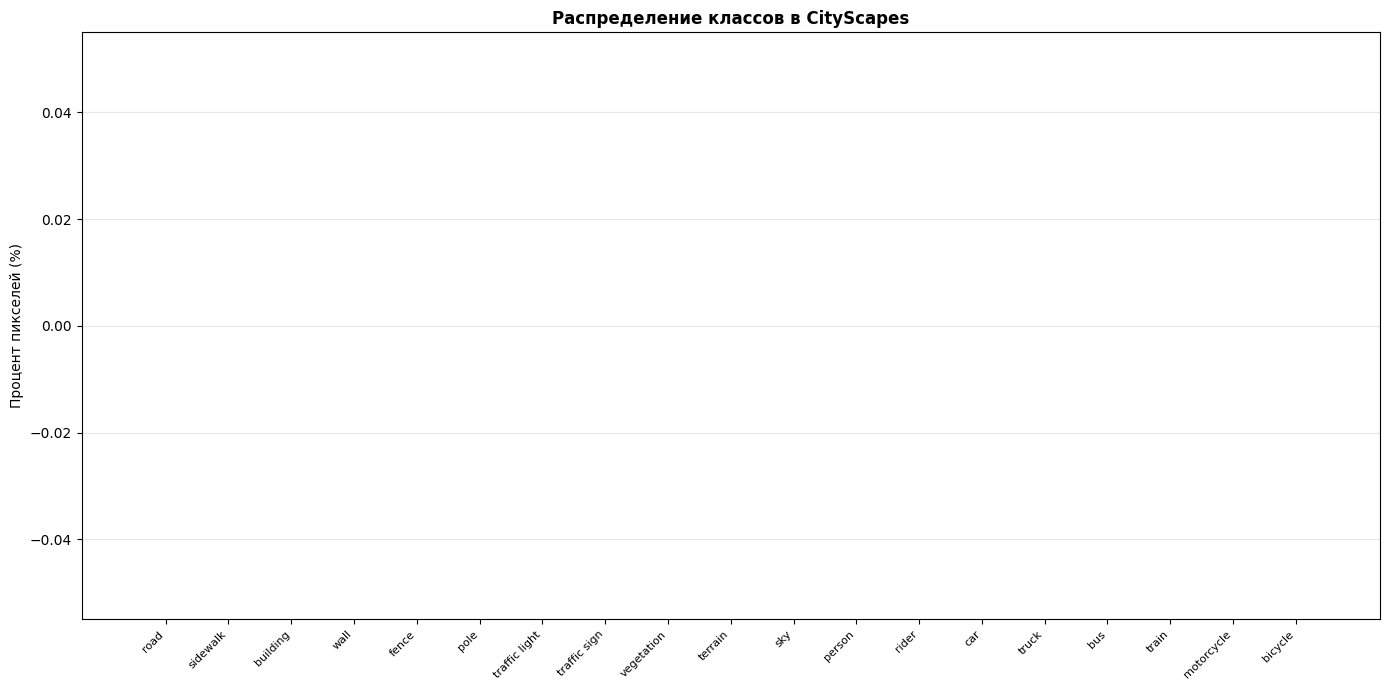


Топ-5 самых частых классов:
  19. bicycle: 0.00%
  18. motorcycle: 0.00%
  17. train: 0.00%
  16. bus: 0.00%
  15. truck: 0.00%

Топ-5 самых редких классов:
  1. road: 0.00%
  2. sidewalk: 0.00%
  3. building: 0.00%
  4. wall: 0.00%
  5. fence: 0.00%
Не найдено примеров для сплита 'train'
Не найдено примеров для сплита 'val'


In [13]:
if __name__ == '__main__':
    load_dotenv()
    DOWNLOAD_DIR = os.getenv('DOWNLOAD_DIR')

    is_valid, report = verify_cityscapes_structure(DOWNLOAD_DIR)

    if report['warnings']:

        print("\nПредупреждения:")

        for w in report['warnings']:

            print(f"  ! {w}")



    if not is_valid:

        print("\nКритические ошибки! Остановка.")

        exit(1)

    try:

        train_img_dir = os.path.join(DOWNLOAD_DIR, 'leftImg8bit', 'train')

        train_mask_dir = os.path.join(DOWNLOAD_DIR, 'gtFine', 'train')



        cities = os.listdir(train_img_dir)

        if cities:

            first_city = cities[0]

            city_img_path = os.path.join(train_img_dir, first_city)

            city_mask_path = os.path.join(train_mask_dir, first_city)



            integrity_results = check_dataset_integrity(city_img_path, city_mask_path)

    except Exception as e:

        print(f"Ошибка при проверке целостности: {e}")



    try:

        mask_train_dir = os.path.join(DOWNLOAD_DIR, 'gtFine', 'train')

        plot_class_distribution_bar(

            mask_train_dir,

            output_path=os.path.join(DOWNLOAD_DIR, 'class_distribution.png')

        )

    except Exception as e:

        print(f"Ошибка при анализе распределения: {e}")



    try:

        for split in ['train', 'val']:

            try:

                img_path, mask_path = find_sample_pair(DOWNLOAD_DIR, split)

                output_path = os.path.join(DOWNLOAD_DIR, f'sample_{split}.png')

                visualize_sample(img_path, mask_path, output_path=output_path)

            except FileNotFoundError:

                print(f"Не найдено примеров для сплита '{split}'")

    except Exception as e:

        print(f"Ошибка при визуализации: {e}")